[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/06_vit_b16.ipynb)

# ViT-B/16

**CSC3109 - Machine Learning | Team 16 - Jun Hao**

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally — skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import TRAIN_DIR, VAL_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")

ROOT   : /content/CSC3109-T16-Project
Device : cuda
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']


## 1. Data Loading

In [3]:
from src.dataset import get_dataloaders

train_loader, val_loader, classes = get_dataloaders(
    root        = ROOT,
    train_dir   = TRAIN_DIR,
    val_dir     = VAL_DIR,
    batch_size  = BATCH_SIZE,
    image_size  = IMAGE_SIZE,
    num_workers = 2,
)

print(f"Classes    : {classes}")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} images)")

Classes    : ['beach', 'ferry_terminal', 'harbor', 'river']
Train batches : 88  (2800 images)
Val batches   : 13  (400 images)


## 2. Model Setup

ViT-B/16 splits each 224×224 image into 16×16 patches (196 patches total) and processes them through 12 transformer encoder blocks. We load ImageNet pretrained weights and replace only the classification head for our 4 classes.

In [4]:
from src.models import get_vit_b16
from src.utils import count_parameters

model = get_vit_b16(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

total_params     = count_parameters(model)
print(f"Trainable parameters : {total_params / 1e6:.2f} M")
print(f"Model head           : {model.heads.head}")
print(f"Running on           : {DEVICE}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 158MB/s]


Trainable parameters : 85.80 M
Model head           : Linear(in_features=768, out_features=4, bias=True)
Running on           : cuda


## 3. Training

ViT fine-tuning is sensitive to learning rate — we use **AdamW** with a small lr (1e-4) and **CosineAnnealingLR** to decay smoothly. This avoids destroying the pretrained representations.

In [5]:
import torch
from pathlib import Path
from src.train import train

SAVE_PATH = ROOT / "results" / "saved_models" / "vit_b16.pth"
LR        = 1e-4
WD        = 0.01

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = train(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    optimizer    = optimizer,
    scheduler    = scheduler,
    num_epochs   = NUM_EPOCHS,
    device       = DEVICE,
    save_path    = SAVE_PATH,
)

Epoch [01/20]  train loss: 0.1556  train acc: 0.9414  val loss: 0.1951  val acc: 0.9225  (104.6s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/vit_b16.pth  (val_acc=0.9225)
Epoch [02/20]  train loss: 0.0535  train acc: 0.9818  val loss: 0.1578  val acc: 0.9475  (106.1s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/vit_b16.pth  (val_acc=0.9475)
Epoch [03/20]  train loss: 0.0584  train acc: 0.9761  val loss: 0.1303  val acc: 0.9675  (106.6s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/vit_b16.pth  (val_acc=0.9675)
Epoch [04/20]  train loss: 0.0637  train acc: 0.9782  val loss: 0.1243  val acc: 0.9625  (106.6s)
Epoch [05/20]  train loss: 0.0656  train acc: 0.9779  val loss: 0.1280  val acc: 0.9525  (106.9s)
Epoch [06/20]  train loss: 0.0501  train acc: 0.9804  val loss: 0.1496  val acc: 0.9500  (106.7s)
Epoch [07/20]  train loss: 0.0428  train acc: 0.9846  val loss: 0.3349  val acc: 0.8650  (106.3s)

## 4. Training Curves

Training curves saved to /content/CSC3109-T16-Project/results/training_curves/vit_b16.png


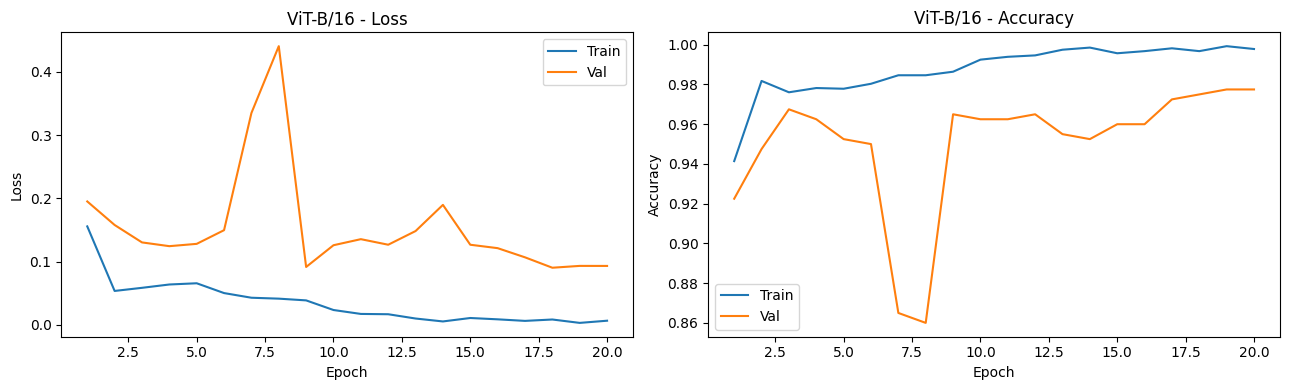

In [6]:
from src.utils import plot_training_curves

CURVES_PATH = ROOT / "results" / "training_curves" / "vit_b16.png"

plot_training_curves(history, title="ViT-B/16", save_path=CURVES_PATH)

## 5. Evaluation

In [7]:
import torch
from src.evaluate import get_predictions, compute_metrics, print_report

# Load best saved weights before evaluating
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

y_pred, y_true = get_predictions(model, val_loader, DEVICE)
metrics        = compute_metrics(y_true, y_pred)

print("=" * 40)
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print("=" * 40)
print()
print_report(y_true, y_pred, CLASS_NAMES)

  Accuracy  : 0.9775
  Precision : 0.9781
  Recall    : 0.9775
  F1 Score  : 0.9775

                precision    recall  f1-score   support

         beach       1.00      1.00      1.00       100
ferry_terminal       0.98      0.93      0.95       100
        harbor       0.93      0.98      0.96       100
         river       1.00      1.00      1.00       100

      accuracy                           0.98       400
     macro avg       0.98      0.98      0.98       400
  weighted avg       0.98      0.98      0.98       400



## 6. Confusion Matrix

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/vit_b16.png


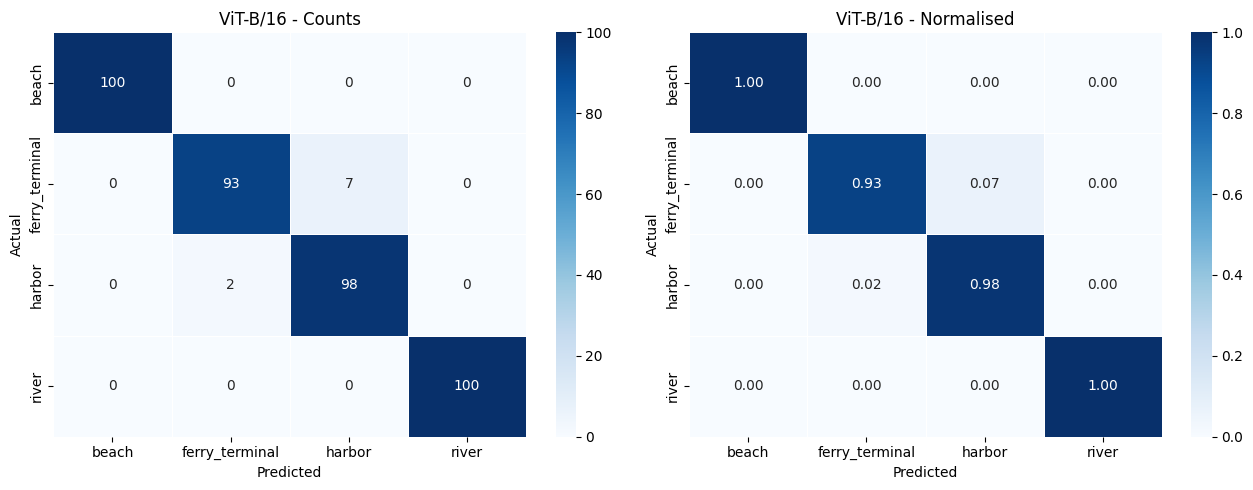

In [8]:
from src.evaluate import plot_confusion_matrix

CM_PATH = ROOT / "results" / "confusion_matrices" / "vit_b16.png"

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title="ViT-B/16", save_path=CM_PATH)

## 7. Save Metrics

In [9]:
from src.utils import save_metrics_to_csv

METRICS_PATH = ROOT / "results" / "metrics.csv"

save_metrics_to_csv("vit_b16", metrics, METRICS_PATH)
print("Results written to results/metrics.csv")

Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Results written to results/metrics.csv


## 8. Sample Predictions

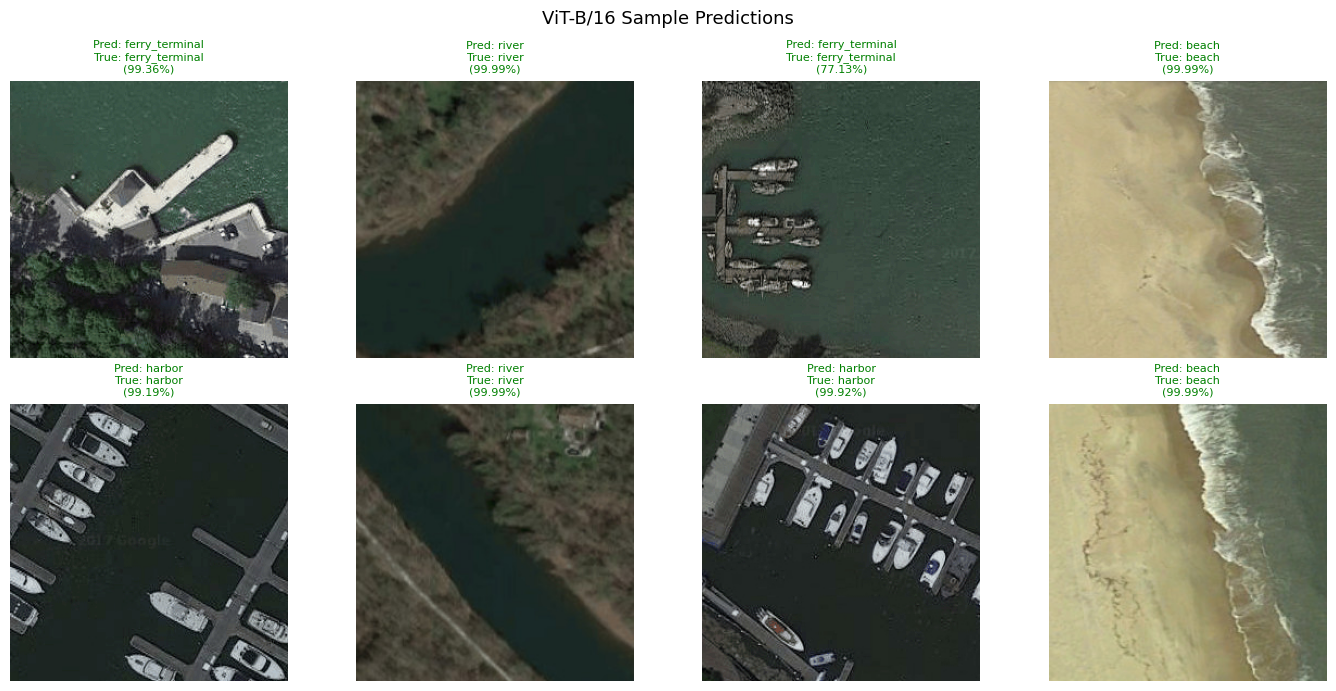

In [10]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from src.predict import predict_image

VAL_ROOT = ROOT / VAL_DIR
sample_paths = []
for cls in CLASS_NAMES:
    imgs = list((VAL_ROOT / cls).glob("*.*"))
    sample_paths.extend(random.sample(imgs, min(2, len(imgs))))

random.shuffle(sample_paths)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("ViT-B/16 Sample Predictions", fontsize=13)

for ax, path in zip(axes.flat, sample_paths[:8]):
    label, conf, _ = predict_image(path, model, CLASS_NAMES, DEVICE, IMAGE_SIZE)
    true_cls = path.parent.name
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    color = "green" if label == true_cls else "red"
    ax.set_title(f"Pred: {label}\nTrue: {true_cls}\n({conf:.2%})", fontsize=8, color=color)

plt.tight_layout()
plt.show()